# Question 6: Derivative of Gaussian

- **(a)** Show that the first-order partial derivatives of the 2D Gaussian are given by:
  $$\frac{\partial G}{\partial x} = -\frac{x}{\sigma^2}G(x,y), \quad \frac{\partial G}{\partial y} = -\frac{y}{\sigma^2}G(x,y)$$
- **(b)** Compute normalized 5×5 DoG kernels in x and y directions (σ=2) using NumPy
- **(c)** Visualize a 51×51 DoG kernel as a 3D surface plot
- **(d)** Apply DoG kernels to get image gradients (horizontal & vertical)
- **(e)** Compare with `cv.Sobel()` and comment on differences

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
%matplotlib inline

## (a) Mathematical Derivation of the Partial Derivatives

The 2D Gaussian function is:

$$G(x, y) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$

**Derivation of ∂G/∂x:**

Using the chain rule, let $u = -\dfrac{x^2 + y^2}{2\sigma^2}$, so $G = \dfrac{1}{2\pi\sigma^2} e^{u}$.

$$\frac{\partial G}{\partial x} = \frac{1}{2\pi\sigma^2} \cdot e^{u} \cdot \frac{\partial u}{\partial x}$$

$$\frac{\partial u}{\partial x} = -\frac{2x}{2\sigma^2} = -\frac{x}{\sigma^2}$$

Therefore:

$$\boxed{\frac{\partial G}{\partial x} = -\frac{x}{\sigma^2} \cdot \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}} = -\frac{x}{\sigma^2} G(x,y)}$$

**Derivation of ∂G/∂y:**

By symmetry (y appears identically to x in G):

$$\frac{\partial u}{\partial y} = -\frac{y}{\sigma^2}$$

Therefore:

$$\boxed{\frac{\partial G}{\partial y} = -\frac{y}{\sigma^2} G(x,y)}$$

**Interpretation:** The derivative kernels are antisymmetric (odd functions). ∂G/∂x detects **vertical edges** (intensity changes in the horizontal direction), and ∂G/∂y detects **horizontal edges**.

## (b) Compute Normalized 5×5 DoG Kernels (σ = 2)

In [2]:
def gaussian_kernel(size, sigma):
    """Compute a normalized 2D Gaussian kernel (reused from Q5)."""
    half = size // 2
    x = np.arange(-half, half + 1)
    y = np.arange(-half, half + 1)
    X, Y = np.meshgrid(x, y)
    kernel = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    return kernel / kernel.sum()


def dog_kernels(size, sigma):
    """
    Compute normalized Derivative-of-Gaussian kernels in x and y directions.

    From the derivation:
        dG/dx = -(x / sigma^2) * G(x, y)
        dG/dy = -(y / sigma^2) * G(x, y)

    Normalization: divide by sum of absolute values so the kernel
    response is scale-independent.

    Parameters
    ----------
    size  : int   - kernel size (must be odd)
    sigma : float - standard deviation

    Returns
    -------
    dG_dx : np.ndarray (size x size) — x-direction derivative kernel
    dG_dy : np.ndarray (size x size) — y-direction derivative kernel
    """
    half = size // 2
    x = np.arange(-half, half + 1)
    y = np.arange(-half, half + 1)
    X, Y = np.meshgrid(x, y)

    # Unnormalized Gaussian
    G = np.exp(-(X**2 + Y**2) / (2 * sigma**2))

    # Apply the derived formula
    dG_dx = -(X / sigma**2) * G
    dG_dy = -(Y / sigma**2) * G

    # Normalize by sum of absolute values
    dG_dx = dG_dx / np.sum(np.abs(dG_dx))
    dG_dy = dG_dy / np.sum(np.abs(dG_dy))

    return dG_dx, dG_dy


sigma = 2
dG_dx, dG_dy = dog_kernels(size=5, sigma=sigma)

print(f'5×5 DoG Kernel — x direction (σ={sigma}):')
print(np.array2string(dG_dx, precision=4, suppress_small=True))
print(f'\n5×5 DoG Kernel — y direction (σ={sigma}):')
print(np.array2string(dG_dy, precision=4, suppress_small=True))
print(f'\nSum of dG_dx (should be ~0): {dG_dx.sum():.6f}')
print(f'Sum of dG_dy (should be ~0): {dG_dy.sum():.6f}')

5×5 DoG Kernel — x direction (σ=2):
[[ 0.0441  0.0321 -0.     -0.0321 -0.0441]
 [ 0.0642  0.0467 -0.     -0.0467 -0.0642]
 [ 0.0728  0.0529 -0.     -0.0529 -0.0728]
 [ 0.0642  0.0467 -0.     -0.0467 -0.0642]
 [ 0.0441  0.0321 -0.     -0.0321 -0.0441]]

5×5 DoG Kernel — y direction (σ=2):
[[ 0.0441  0.0642  0.0728  0.0642  0.0441]
 [ 0.0321  0.0467  0.0529  0.0467  0.0321]
 [-0.     -0.     -0.     -0.     -0.    ]
 [-0.0321 -0.0467 -0.0529 -0.0467 -0.0321]
 [-0.0441 -0.0642 -0.0728 -0.0642 -0.0441]]

Sum of dG_dx (should be ~0): 0.000000
Sum of dG_dy (should be ~0): 0.000000


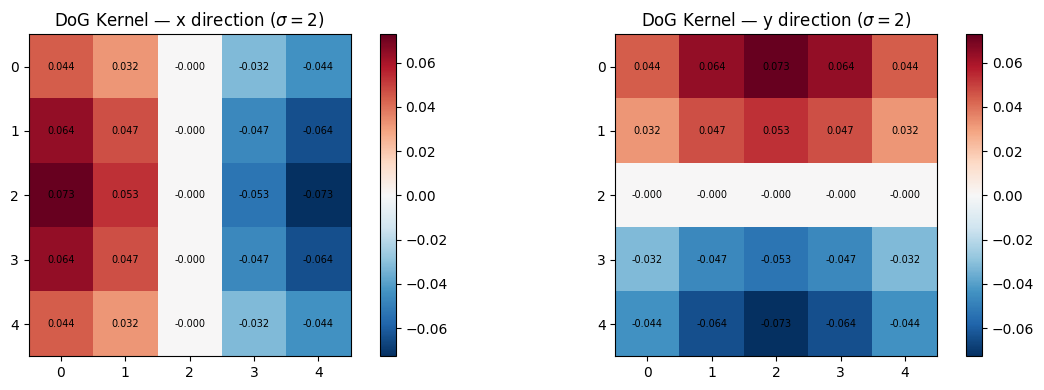

In [3]:
# Visualise the 5x5 kernels as heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(dG_dx, cmap='RdBu_r', interpolation='nearest')
plt.colorbar(im0, ax=axes[0])
axes[0].set_title(rf'DoG Kernel — x direction ($\sigma={sigma}$)')
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, f'{dG_dx[i,j]:.3f}', ha='center', va='center', fontsize=7)

im1 = axes[1].imshow(dG_dy, cmap='RdBu_r', interpolation='nearest')
plt.colorbar(im1, ax=axes[1])
axes[1].set_title(rf'DoG Kernel — y direction ($\sigma={sigma}$)')
for i in range(5):
    for j in range(5):
        axes[1].text(j, i, f'{dG_dy[i,j]:.3f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('output/q6b_dog_kernels_5x5.png', dpi=150, bbox_inches='tight')
plt.show()

## (c) Visualize a 51×51 DoG Kernel as a 3D Surface Plot

We visualize the **x-direction** kernel. Notice the antisymmetric shape — negative on one side, positive on the other — this is what detects edges.

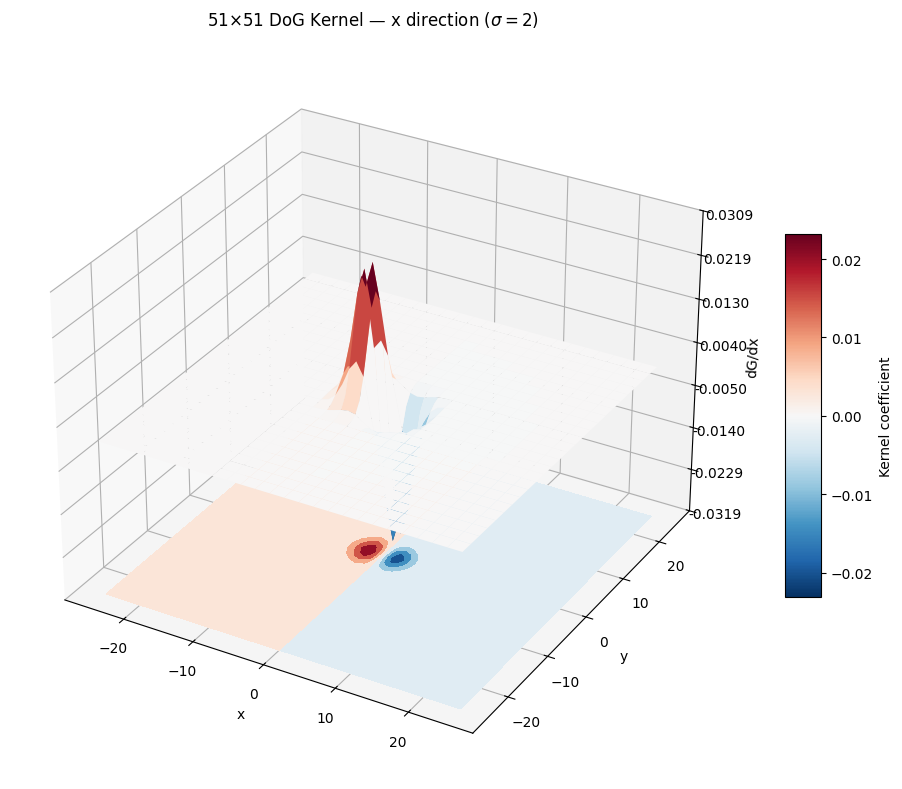

In [5]:
# Compute 51x51 DoG kernels
dG_dx_51, dG_dy_51 = dog_kernels(size=51, sigma=sigma)

# Coordinate grid for plotting
half = 51 // 2
x = np.arange(-half, half + 1)
y = np.arange(-half, half + 1)
X, Y = np.meshgrid(x, y)

# 3D surface — x direction kernel
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, dG_dx_51, cmap=cm.RdBu_r,
                       linewidth=0, antialiased=True)

ax.zaxis.set_major_locator(LinearLocator(8))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.4f'))

cset = ax.contourf(X, Y, dG_dx_51, zdir='z',
                   offset=dG_dx_51.min() - 0.001, cmap=cm.RdBu_r)
ax.set_zlim(dG_dx_51.min() - 0.001, dG_dx_51.max())

fig.colorbar(surf, shrink=0.5, aspect=10, label='Kernel coefficient')
ax.set_title(rf'51×51 DoG Kernel — x direction ($\sigma={sigma}$)', pad=20)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('dG/dx')

plt.tight_layout()
plt.savefig('output/q6c_dog_kernel_51x51_3d.png', dpi=150, bbox_inches='tight')
plt.show()

## Load the Runway Image

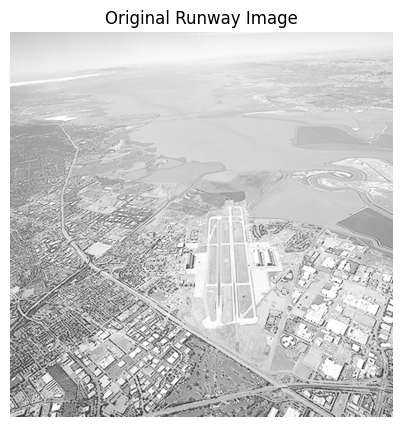

In [6]:
img = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "Could not load runway.png. Check the images/ folder."

plt.figure(figsize=(6, 5))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Original Runway Image')
plt.axis('off')
plt.show()

## (d) Apply DoG Kernels to Get Image Gradients

- Convolving with **dG/dx** gives the gradient in the **horizontal direction** (detects vertical edges)
- Convolving with **dG/dy** gives the gradient in the **vertical direction** (detects horizontal edges)
- The **gradient magnitude** combines both: $|\nabla G| = \sqrt{(\partial G/\partial x)^2 + (\partial G/\partial y)^2}$

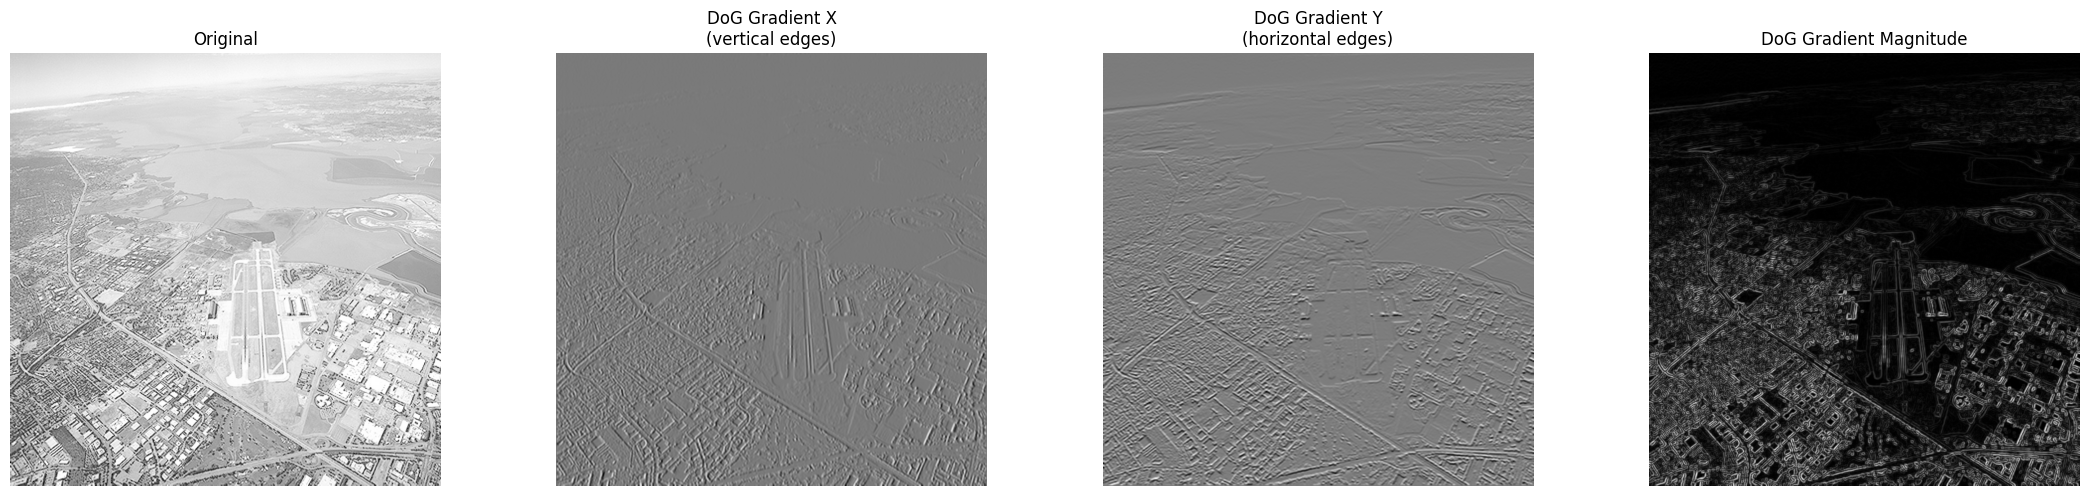

In [7]:
# Apply DoG kernels using cv.filter2D (float output to preserve negatives)
grad_x_dog = cv.filter2D(img, cv.CV_64F, dG_dx.astype(np.float64))
grad_y_dog = cv.filter2D(img, cv.CV_64F, dG_dy.astype(np.float64))

# Gradient magnitude
mag_dog = np.sqrt(grad_x_dog**2 + grad_y_dog**2)

# Normalize to [0, 255] for display
def normalize_display(img):
    """Normalize image to [0, 255] for display."""
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max() * 255
    return img.astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(normalize_display(grad_x_dog), cmap='gray')
axes[1].set_title('DoG Gradient X\n(vertical edges)')
axes[1].axis('off')

axes[2].imshow(normalize_display(grad_y_dog), cmap='gray')
axes[2].set_title('DoG Gradient Y\n(horizontal edges)')
axes[2].axis('off')

axes[3].imshow(normalize_display(mag_dog), cmap='gray')
axes[3].set_title('DoG Gradient Magnitude')
axes[3].axis('off')

plt.tight_layout()
plt.savefig('output/q6d_dog_gradients.png', dpi=150, bbox_inches='tight')
plt.show()

## (e) Compare with `cv.Sobel()` and Comment on Differences

The Sobel operator uses fixed 3×3 kernels:
$$K_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}, \quad
K_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

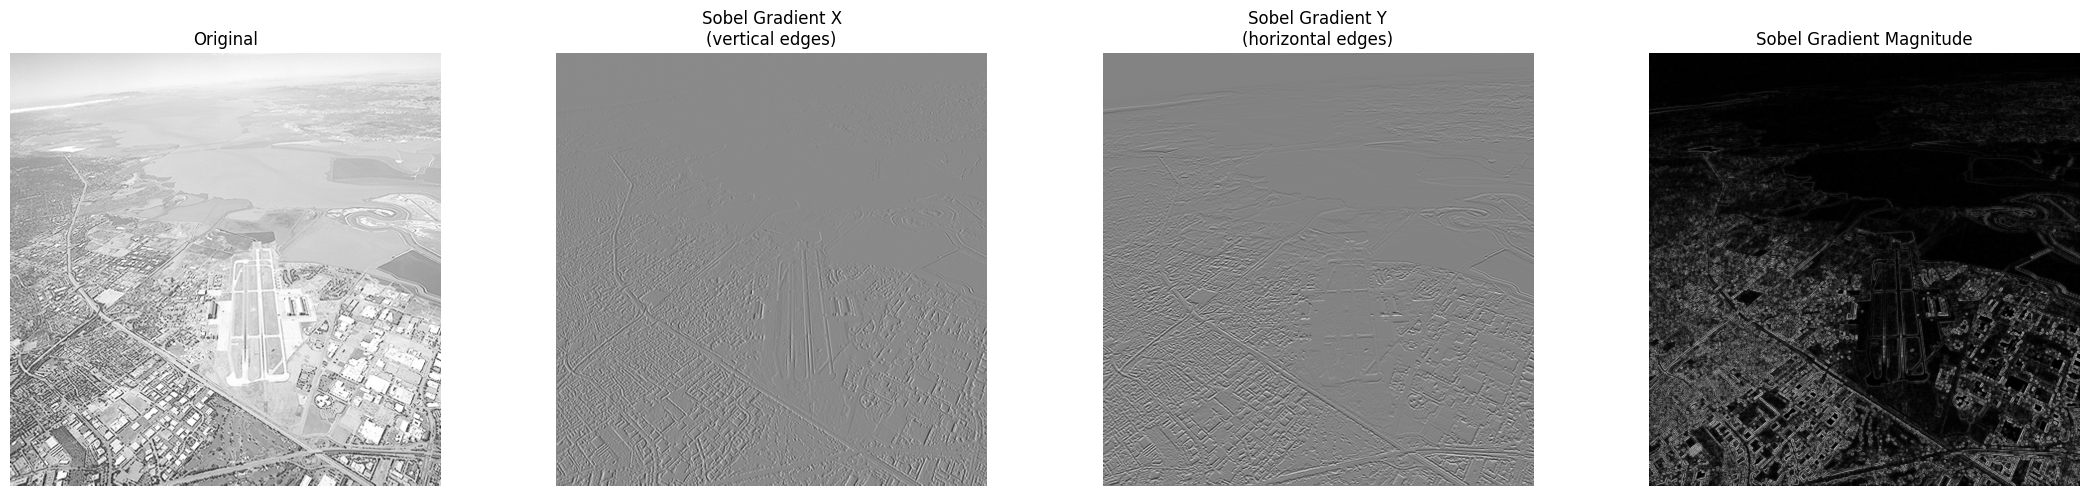

In [8]:
# Apply Sobel operator using OpenCV
# ddepth=cv.CV_64F to capture both positive and negative gradients
grad_x_sobel = cv.Sobel(img, cv.CV_64F, dx=1, dy=0, ksize=3)
grad_y_sobel = cv.Sobel(img, cv.CV_64F, dx=0, dy=1, ksize=3)
mag_sobel = np.sqrt(grad_x_sobel**2 + grad_y_sobel**2)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(normalize_display(grad_x_sobel), cmap='gray')
axes[1].set_title('Sobel Gradient X\n(vertical edges)')
axes[1].axis('off')

axes[2].imshow(normalize_display(grad_y_sobel), cmap='gray')
axes[2].set_title('Sobel Gradient Y\n(horizontal edges)')
axes[2].axis('off')

axes[3].imshow(normalize_display(mag_sobel), cmap='gray')
axes[3].set_title('Sobel Gradient Magnitude')
axes[3].axis('off')

plt.tight_layout()
plt.savefig('output/q6e_sobel_gradients.png', dpi=150, bbox_inches='tight')
plt.show()

## Side-by-Side Comparison — DoG vs Sobel

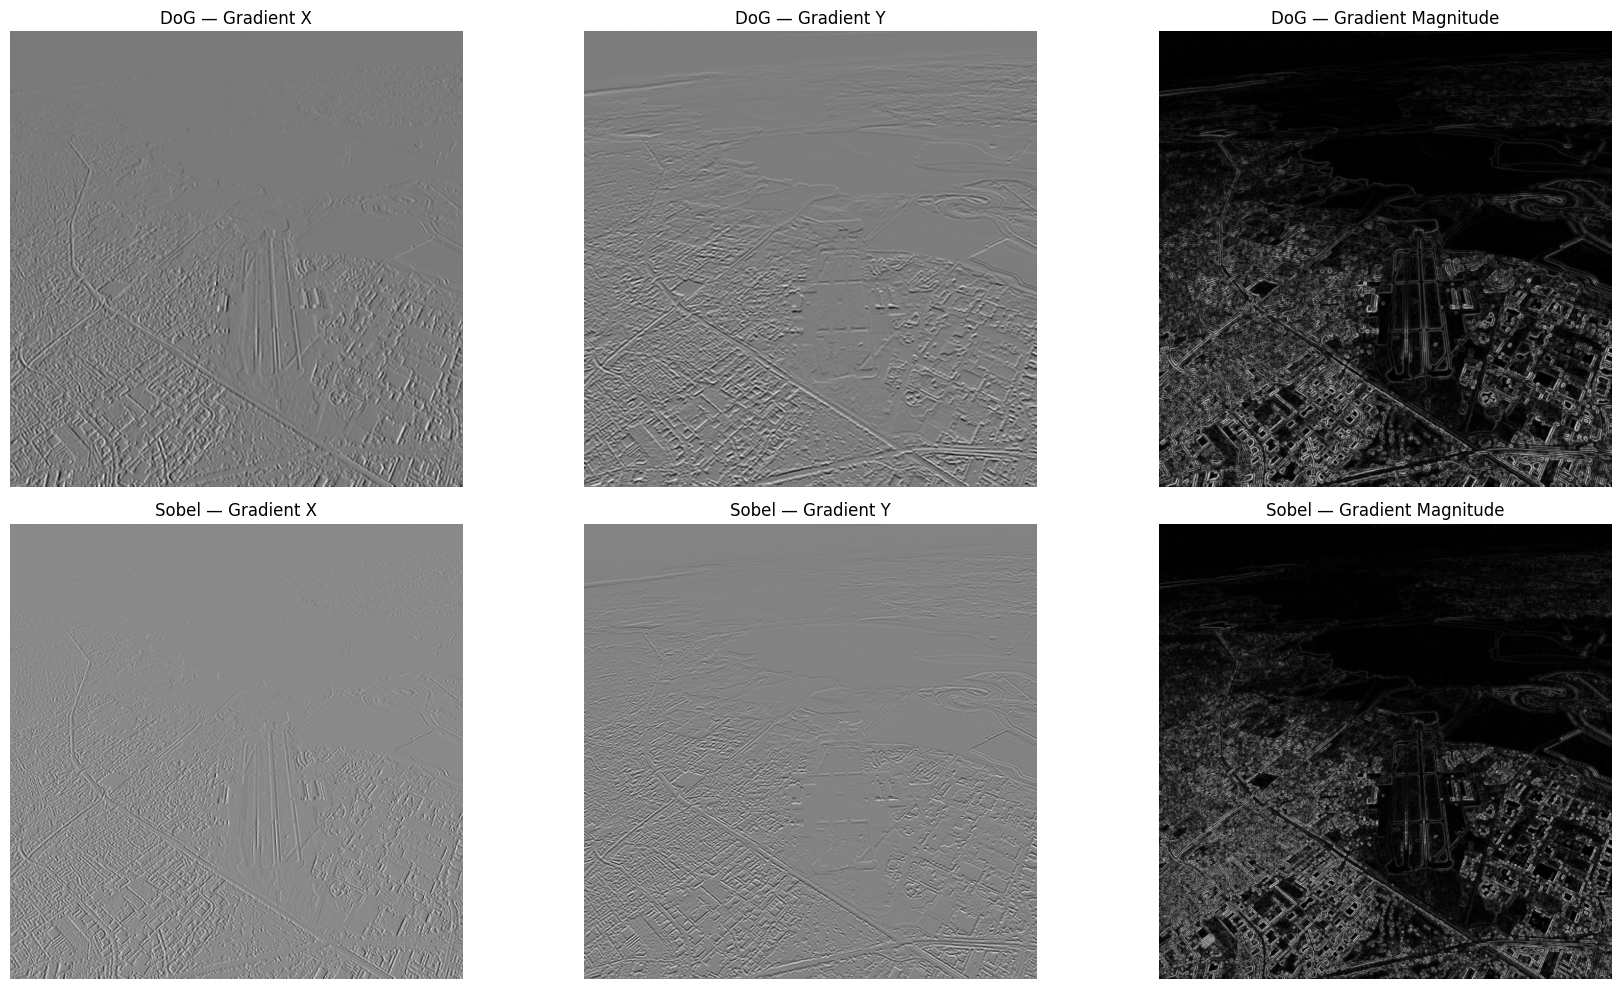

Key differences between DoG and Sobel:

1. SMOOTHING: DoG (σ=2, 5×5) applies more smoothing before differentiating,
   so it is less sensitive to noise. Sobel (3×3) applies minimal smoothing.

2. KERNEL SIZE: Sobel uses a fixed 3×3 kernel. DoG kernel size is flexible
   and controlled by σ — larger σ detects coarser/broader edges.

3. EDGE SHARPNESS: Sobel produces sharper, thinner edge responses.
   DoG edges are smoother and wider due to the Gaussian pre-smoothing.

4. NOISE SENSITIVITY: Sobel is more sensitive to fine noise.
   DoG suppresses noise better because of the built-in Gaussian smoothing.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].imshow(normalize_display(grad_x_dog), cmap='gray')
axes[0, 0].set_title('DoG — Gradient X')
axes[0, 0].axis('off')

axes[0, 1].imshow(normalize_display(grad_y_dog), cmap='gray')
axes[0, 1].set_title('DoG — Gradient Y')
axes[0, 1].axis('off')

axes[0, 2].imshow(normalize_display(mag_dog), cmap='gray')
axes[0, 2].set_title('DoG — Gradient Magnitude')
axes[0, 2].axis('off')

axes[1, 0].imshow(normalize_display(grad_x_sobel), cmap='gray')
axes[1, 0].set_title('Sobel — Gradient X')
axes[1, 0].axis('off')

axes[1, 1].imshow(normalize_display(grad_y_sobel), cmap='gray')
axes[1, 1].set_title('Sobel — Gradient Y')
axes[1, 1].axis('off')

axes[1, 2].imshow(normalize_display(mag_sobel), cmap='gray')
axes[1, 2].set_title('Sobel — Gradient Magnitude')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('output/q6_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key differences between DoG and Sobel:')
print()
print('1. SMOOTHING: DoG (σ=2, 5×5) applies more smoothing before differentiating,')
print('   so it is less sensitive to noise. Sobel (3×3) applies minimal smoothing.')
print()
print('2. KERNEL SIZE: Sobel uses a fixed 3×3 kernel. DoG kernel size is flexible')
print('   and controlled by σ — larger σ detects coarser/broader edges.')
print()
print('3. EDGE SHARPNESS: Sobel produces sharper, thinner edge responses.')
print('   DoG edges are smoother and wider due to the Gaussian pre-smoothing.')
print()
print('4. NOISE SENSITIVITY: Sobel is more sensitive to fine noise.')
print('   DoG suppresses noise better because of the built-in Gaussian smoothing.')